# AgroScan — Jalon 4 : Classification hiérarchique à deux étages

## Idée

Au lieu d'un seul modèle plat à N classes (`Tomate___Mildiou`, `Maïs___Rouille`, ...),
on décompose le diagnostic en deux niveaux :

1. **Étage 1 — Détecteur d'espèce.** Un modèle qui répond *« quelle plante ? »*
   (tomate, maïs, pomme, ...). C'est un problème **plus facile et plus robuste au
   décalage de domaine** : la forme/texture d'une feuille de tomate transfère bien
   du studio au terrain.
2. **Étage 2 — Spécialistes maladie.** Un modèle **par espèce** qui répond
   *« saine ou malade, et quelle maladie ? »*, conditionné sur l'espèce déjà connue.
   Chaque spécialiste n'a que peu de classes → moins de confusions inter-espèces.

**Prédiction finale (jointe) :** `P(classe) = P(espèce) · P(maladie | espèce)`.
Ce produit donne naturellement les **top-1 / top-2 / top-3**.

## Critique de l'approche hiérarchique (pour mémoire)

- **Atout :** l'étage espèce est fiable et robuste ; chaque spécialiste a une tâche nette.
- **Risque 1 — propagation d'erreur :** une mauvaise espèce condamne l'étage 2.
- **Risque 2 — fragmentation des données :** PlantDoc a peu d'images ; les découper
  par espèce en laisse encore moins par spécialiste.
- **Risque 3 — espèces mono-classe :** sur 13 espèces, **7 n'ont qu'une seule classe**
  dans PlantDoc (Blueberry, Cherry, Peach, Raspberry, Soybean, Squash, Strawberry) →
  pas de vrai spécialiste à entraîner (réponse triviale). Seules **6 espèces** ont
  plusieurs maladies : **Tomato, Apple, Corn, Grape, Pepper bell, Potato**.
- **Piste alternative (souvent supérieure) :** un seul modèle multi-têtes (tête espèce
  + tête maladie) partageant le backbone — plus efficace en données, sans propagation
  d'erreur. 

On réutilise la même stratégie d'entraînement que jalon 4 (PV → PlantWild → PlantDoc
avec replay) pour l'étage espèce, et une version condensée pour chaque spécialiste.

## 1. Lancement

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

In [1]:
# %pip install -r ../requirements.txt kagglehub

In [2]:
import shutil
import subprocess
import os
import time
from pathlib import Path
from difflib import SequenceMatcher
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-05-30 02:39:01.013959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780108741.195571      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780108741.248389      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780108741.683293      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780108741.683326      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780108741.683329      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [ ]:
# Détection robuste de la racine projet
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
IS_COLAB  = Path('/content').exists() and Path('/opt/google').exists()
_colab_root = Path('/content') if IS_COLAB else None
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents
])))
ROOT = next(
    (p for p in _candidates if (p / 'requirements.txt').exists()),
    _env_root or _colab_root or _cwd,
)

DATA_DIR   = ROOT / 'data'
MODEL_DIR  = ROOT / 'models'
# MODEL_DIR = Path('/kaggle/working/models')
# MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = ROOT / 'reports'

if IS_COLAB:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount('/content/drive', force_remount=False)
        _drive_root = Path('/content/drive/MyDrive/agroscan')
        MODEL_DIR   = _drive_root / 'models'
        REPORT_DIR  = _drive_root / 'reports'
        print('Google Drive monté → artefacts dans :', _drive_root)
    except Exception as _e:
        print(f'Drive non disponible ({_e}) — sauvegarde locale /content uniquement.')

for d in [MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# Hyperparamètres Étage 1 : détecteur d'espèce 
S1_EPOCHS_P1, S1_LR_P1, S1_PAT_P1 = 12, 1e-3, 3
S1_EPOCHS_P2, S1_LR_P2, S1_PAT_P2, S1_UNFREEZE_P2 = 20, 1e-4, 4, 0.75
S1_EPOCHS_P3, S1_LR_P3, S1_PAT_P3, S1_UNFREEZE_P3 = 40, 3e-5, 8, 0.60
MIX_RATIO_PD, MIX_RATIO_PV = 0.70, 0.30
LABEL_SMOOTHING = 0.05

# Hyperparamètres Étage 2 : spécialistes maladie 
S2_EPOCHS_A, S2_LR_A, S2_PAT_A = 12, 1e-3, 3          # tête seule (backbone gelé)
S2_EPOCHS_B, S2_LR_B, S2_PAT_B, S2_UNFREEZE_B = 25, 3e-5, 6, 0.60  # fine-tune terrain

tf.keras.utils.set_random_seed(SEED)
print('Racine projet:', ROOT)
print('Models      :', MODEL_DIR)

Racine projet: /
Models      : /kaggle/working/models


## 3. Chargement de PlantVillage

In [4]:
(pv_train_raw, pv_val_raw, pv_test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names     = info.features['label'].names
num_classes_pv  = len(class_names)
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes_pv} classes')
print(f'Ex. : {class_names[:5]}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /data/tfds/plant_village/incomplete.HBRPOI_1.0.2/plant_village-train.tfrecord*...:   0%|          | …

Dataset plant_village downloaded and prepared to /data/tfds/plant_village/1.0.2. Subsequent calls will reuse this data.
PlantVillage : 38 classes
Ex. : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


I0000 00:00:1780108942.760801      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780108942.763922      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 4. Configuration PlantDoc + mapping

In [5]:
PLANTDOC_DIR       = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':               'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('Téléchargement de PlantDoc...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp = DATA_DIR / '_pd_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git', str(tmp)],
        check=True,
    )
    for split in ('train', 'test'):
        src, dst = tmp / split, PLANTDOC_DIR / split
        if src.exists() and not dst.exists():
            shutil.copytree(src, dst)
    shutil.rmtree(tmp)
    print('PlantDoc téléchargé.')

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
print(f'PlantDoc test : {len(plantdoc_classes)} classes | {len(valid_pd_mapping)} évaluables')

Téléchargement de PlantDoc...


Cloning into '/data/_pd_clone'...
Updating files: 100% (2581/2581), done.


PlantDoc téléchargé.
PlantDoc test : 27 classes | 27 évaluables


## 5. Univers restreint aux 27 classes PlantDoc

On définit ici **l'univers de travail** : les classes PV qui existent dans PlantDoc.
Tout (PV, PlantWild, PlantDoc) sera filtré sur ce sous-ensemble.

In [ ]:
# Les classes PV autorisées = celles mappées depuis PlantDoc
allowed_pv_names = sorted(set(valid_pd_mapping.values()))
allowed_pv_idx   = [pv_label_to_idx[n] for n in allowed_pv_names]
allowed_set      = set(allowed_pv_idx)
n_allowed        = len(allowed_pv_idx)

# Position contiguë 0..n_allowed-1 pour chaque classe globale autorisée
global_to_pos = {g: pos for pos, g in enumerate(allowed_pv_idx)}
pos_to_name   = {pos: class_names[g] for g, pos in global_to_pos.items()}

allowed_idx_tensor = tf.constant(allowed_pv_idx, dtype=tf.int64)

print(f'Univers restreint : {n_allowed} classes PlantDoc')
for pos in range(n_allowed):
    print(f'  [{pos:2d}] {pos_to_name[pos]}')

Univers restreint : 27 classes PlantDoc
  [ 0] Apple___Apple_scab
  [ 1] Apple___Cedar_apple_rust
  [ 2] Apple___healthy
  [ 3] Blueberry___healthy
  [ 4] Cherry___healthy
  [ 5] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [ 6] Corn___Common_rust
  [ 7] Corn___Northern_Leaf_Blight
  [ 8] Grape___Black_rot
  [ 9] Grape___healthy
  [10] Peach___healthy
  [11] Pepper,_bell___Bacterial_spot
  [12] Pepper,_bell___healthy
  [13] Potato___Early_blight
  [14] Potato___Late_blight
  [15] Raspberry___healthy
  [16] Soybean___healthy
  [17] Squash___Powdery_mildew
  [18] Strawberry___healthy
  [19] Tomato___Bacterial_spot
  [20] Tomato___Early_blight
  [21] Tomato___Late_blight
  [22] Tomato___Leaf_Mold
  [23] Tomato___Septoria_leaf_spot
  [24] Tomato___Tomato_Yellow_Leaf_Curl_Virus
  [25] Tomato___Tomato_mosaic_virus
  [26] Tomato___healthy


## 6. Taxonomie espèce / maladie

On parse chaque nom PV `Espèce___Maladie` pour construire :
- la liste des **espèces** (étage 1),
- pour chaque espèce, la liste de ses **maladies** présentes dans l'univers (étage 2).

In [ ]:
def species_of(pv_name):
    return pv_name.split('___')[0]

# Espèces présentes dans l'univers restreint
species_names = sorted(set(species_of(n) for n in allowed_pv_names))
species_to_idx = {s: i for i, s in enumerate(species_names)}
n_species = len(species_names)

def clean_name(s):
    out = s
    for ch in (',', ' ', '(', ')', '/', '\\'):
        out = out.replace(ch, '_')
    while '__' in out:
        out = out.replace('__', '_')
    return out.strip('_')

species_display = [clean_name(s) for s in species_names]

# pv_idx (0..37) -> species_idx (0..n_species-1) ; -1 si hors univers
pv_to_species_arr = np.full(num_classes_pv, -1, dtype=np.int64)
for g in allowed_pv_idx:
    pv_to_species_arr[g] = species_to_idx[species_of(class_names[g])]
pv_to_species_tensor = tf.constant(pv_to_species_arr, dtype=tf.int64)

# species_idx -> liste triée des classes globales (maladies) de cette espèce
species_disease_global = {s: [] for s in range(n_species)}
for g in allowed_pv_idx:
    species_disease_global[species_to_idx[species_of(class_names[g])]].append(g)
for s in species_disease_global:
    species_disease_global[s] = sorted(species_disease_global[s])

# global_to_local[species] : tensor taille 38 -> indice local de la maladie
global_to_local_tensors = {}
for s in range(n_species):
    arr = np.zeros(num_classes_pv, dtype=np.int64)
    for local, g in enumerate(species_disease_global[s]):
        arr[g] = local
    global_to_local_tensors[s] = tf.constant(arr, dtype=tf.int64)

multi_species = [s for s in range(n_species) if len(species_disease_global[s]) > 1]
mono_species  = [s for s in range(n_species) if len(species_disease_global[s]) == 1]

print(f'{n_species} espèces : {species_display}')
print(f'\n{len(multi_species)} espèces multi-maladies (spécialiste requis) :')
for s in multi_species:
    diseases = [class_names[g].split("___")[1] for g in species_disease_global[s]]
    print(f'  {species_display[s]:14s} ({len(diseases)}) : {diseases}')
print(f'\n{len(mono_species)} espèces mono-classe (réponse triviale) :')
for s in mono_species:
    print(f'  {species_display[s]:14s} : {class_names[species_disease_global[s][0]]}')

13 espèces : ['Apple', 'Blueberry', 'Cherry', 'Corn', 'Grape', 'Peach', 'Pepper_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']

6 espèces multi-maladies (spécialiste requis) :
  Apple          (3) : ['Apple_scab', 'Cedar_apple_rust', 'healthy']
  Corn           (3) : ['Cercospora_leaf_spot Gray_leaf_spot', 'Common_rust', 'Northern_Leaf_Blight']
  Grape          (2) : ['Black_rot', 'healthy']
  Pepper_bell    (2) : ['Bacterial_spot', 'healthy']
  Potato         (2) : ['Early_blight', 'Late_blight']
  Tomato         (8) : ['Bacterial_spot', 'Early_blight', 'healthy', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Tomato_mosaic_virus', 'Tomato_Yellow_Leaf_Curl_Virus']

7 espèces mono-classe (réponse triviale) :
  Blueberry      : Blueberry___healthy
  Cherry         : Cherry___healthy
  Peach          : Peach___healthy
  Raspberry      : Raspberry___healthy
  Soybean        : Soybean___healthy
  Squash         : Squash___Powdery_mildew
  Strawberry     : St

## 7. Chargement et mapping de PlantWild

In [8]:
PLANTWILD_DIR = DATA_DIR / 'plantwild'

if not PLANTWILD_DIR.exists():
    print('PlantWild non trouvé. Tentative de téléchargement via kagglehub...')
    try:
        import kagglehub
        path = kagglehub.dataset_download('thuanai1/plantwild')
        PLANTWILD_DIR = Path(path)
        print('Téléchargé dans :', PLANTWILD_DIR)
    except Exception as e:
        raise FileNotFoundError(
            f'PlantWild non trouvé ({e}).\n'
            'Télécharger sur https://www.kaggle.com/datasets/thuanai1/plantwild\n'
            'et extraire dans data/plantwild/ (train/ val/)'
        ) from e

for candidate in [PLANTWILD_DIR, PLANTWILD_DIR / 'plantwild', *list(PLANTWILD_DIR.iterdir())]:
    if (candidate / 'train').exists():
        PLANTWILD_TRAIN_DIR = candidate / 'train'
        PLANTWILD_VAL_DIR   = candidate / 'val'
        break
else:
    raise FileNotFoundError(f'Structure train/ introuvable dans {PLANTWILD_DIR}')

print('PlantWild train :', PLANTWILD_TRAIN_DIR)

PlantWild non trouvé. Tentative de téléchargement via kagglehub...
Téléchargé dans : /kaggle/input/datasets/thuanai1/plantwild
PlantWild train : /kaggle/input/datasets/thuanai1/plantwild/train


In [9]:
plantwild_to_plantvillage = {
    'apple scab':                    'Apple___Apple_scab',
    'apple black rot':               'Apple___Black_rot',
    'apple rust':                    'Apple___Cedar_apple_rust',
    'apple leaf':                    'Apple___healthy',
    'blueberry leaf':                'Blueberry___healthy',
    'cherry leaf':                   'Cherry___healthy',
    'cherry powdery mildew':         'Cherry___Powdery_mildew',
    'corn gray leaf spot':           'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight':              'Corn___Northern_Leaf_Blight',
    'corn rust':                     'Corn___Common_rust',
    'corn leaf':                     'Corn___healthy',
    'grape black rot':               'Grape___Black_rot',
    'grape esca':                    'Grape___Esca_(Black_Measles)',
    'grape leaf blight':             'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf':                    'Grape___healthy',
    'orange citrus greening':        'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing':          'Orange___Haunglongbing_(Citrus_greening)',
    'peach bacterial spot':          'Peach___Bacterial_spot',
    'peach leaf':                    'Peach___healthy',
    'bell pepper leaf spot':         'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf':              'Pepper,_bell___healthy',
    'potato early blight':           'Potato___Early_blight',
    'potato late blight':            'Potato___Late_blight',
    'potato leaf':                   'Potato___healthy',
    'raspberry leaf':                'Raspberry___healthy',
    'soybean leaf':                  'Soybean___healthy',
    'squash powdery mildew':         'Squash___Powdery_mildew',
    'strawberry leaf scorch':        'Strawberry___Leaf_scorch',
    'strawberry leaf':               'Strawberry___healthy',
    'tomato bacterial spot':         'Tomato___Bacterial_spot',
    'tomato early blight':           'Tomato___Early_blight',
    'tomato late blight':            'Tomato___Late_blight',
    'tomato leaf mold':              'Tomato___Leaf_Mold',
    'tomato septoria leaf spot':     'Tomato___Septoria_leaf_spot',
    'tomato spider mites':           'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot':            'Tomato___Target_Spot',
    'tomato yellow leaf curl virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus':           'Tomato___Tomato_mosaic_virus',
    'tomato leaf':                   'Tomato___healthy',
}
print(f'Mapping PlantWild → PV : {len(plantwild_to_plantvillage)} entrées')

Mapping PlantWild → PV : 39 entrées


In [ ]:
def fuzzy_match(query, candidates, threshold=0.7):
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best, best_score = c, score
    return best if best_score >= threshold else None


def load_plantwild_split(split_dir):
    """Retourne (paths, global_pv_labels) en ne gardant que les classes de l'univers."""
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths, labels = [], []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name.lower()
        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            match = fuzzy_match(cls_name, list(plantwild_to_plantvillage.keys()))
            if match:
                pv_cls = plantwild_to_plantvillage[match]
        if pv_cls is None or pv_cls not in pv_label_to_idx:
            continue
        pv_idx = pv_label_to_idx[pv_cls]
        if pv_idx not in allowed_set:        # restriction aux 27 classes
            continue
        for p in cls_dir.iterdir():
            if p.is_file() and p.suffix.lower() in image_exts:
                paths.append(str(p))
                labels.append(pv_idx)
    return paths, labels


pw_train_paths, pw_train_labels = load_plantwild_split(PLANTWILD_TRAIN_DIR)
if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels = load_plantwild_split(PLANTWILD_VAL_DIR)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths  = [pw_train_paths[i]  for i in perm]
    pw_train_labels = [pw_train_labels[i] for i in perm]
    n_val = int(0.2 * len(pw_train_paths))
    pw_val_paths,   pw_val_labels   = pw_train_paths[:n_val],  pw_train_labels[:n_val]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val:],  pw_train_labels[n_val:]

print(f'PlantWild (univers 27) train : {len(pw_train_paths):,} | val : {len(pw_val_labels):,}')
print(f'Classes couvertes : {len(set(pw_train_labels))} / {n_allowed}')

PlantWild (univers 27) train : 7,074 | val : 994
Classes couvertes : 27 / 27


## 8. Collecte des images PlantDoc train (univers 27)

In [11]:
pd_train_paths, pd_train_glob = [], []
for pd_cls, pv_cls in valid_pd_mapping.items():
    cls_dir = PLANTDOC_TRAIN_DIR / pd_cls
    g = pv_label_to_idx.get(pv_cls)
    if g is None or g not in allowed_set or not cls_dir.exists():
        continue
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            pd_train_paths.append(str(p))
            pd_train_glob.append(g)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(pd_train_paths))
pd_train_paths = [pd_train_paths[i] for i in perm]
pd_train_glob  = [pd_train_glob[i]  for i in perm]

n_val_pd = int(0.2 * len(pd_train_paths))
pd_val_paths,   pd_val_glob   = pd_train_paths[:n_val_pd], pd_train_glob[:n_val_pd]
pd_train_paths, pd_train_glob = pd_train_paths[n_val_pd:], pd_train_glob[n_val_pd:]

print(f'PlantDoc train : {len(pd_train_paths):,} | val : {len(pd_val_paths):,}')
print(f'Classes couvertes : {len(set(pd_train_glob))} / {n_allowed}')

PlantDoc train : 1,872 | val : 468
Classes couvertes : 27 / 27


## 9. Augmentation et prétraitement (identiques jalon 4)

In [12]:
def apply_random_blur(image):
    """Flou boîte aléatoire par average pooling (prob. 40 %) — simule défocus terrain."""
    do_blur = tf.cast(tf.random.uniform([]) < 0.4, tf.float32)
    img_4d  = tf.expand_dims(image, 0)
    blurred = tf.nn.avg_pool2d(img_4d, ksize=3, strides=1, padding='SAME')
    blurred = tf.squeeze(blurred, 0)
    return do_blur * blurred + (1.0 - do_blur) * image


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10'),
], name='data_augmentation_standard')

data_augmentation_heavy = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.35, seed=SEED),
    tf.keras.layers.RandomZoom((-0.50, 0.15), seed=SEED),
    tf.keras.layers.RandomContrast(0.6, seed=SEED),
    tf.keras.layers.RandomBrightness(0.4, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=18.0),
        name='gaussian_noise_18'),
    tf.keras.layers.Lambda(apply_random_blur, name='random_blur'),
], name='data_augmentation_heavy')


def preprocess_pv(image, label, augment=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if augment:
        image = data_augmentation(image, training=True)
    return image, label


def load_image(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, label


def load_image_heavy(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = data_augmentation_heavy(img, training=True)
    return img, label

print('Augmentation prête.')

Augmentation prête.


## 10. Fabrique de modèle (MobileNetV3Small)

Une fonction réutilisée pour l'étage espèce **et** chaque spécialiste. Chaque modèle
a son propre backbone (l'énoncé demande des entraînements séparés).

In [13]:
def build_model(n_out, name):
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    base.trainable = False
    inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
    x       = base(inputs, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(n_out, activation='softmax')(x)
    model   = tf.keras.Model(inputs, outputs, name=name)
    return model, base


def set_unfreeze(base, frozen_ratio):
    """Gèle les `frozen_ratio` premières couches du backbone, dégèle le reste."""
    n_total  = len(base.layers)
    n_frozen = int(n_total * frozen_ratio)
    for layer in base.layers[:n_frozen]:
        layer.trainable = False
    for layer in base.layers[n_frozen:]:
        layer.trainable = True
    return n_frozen, n_total


class LabelSmoothingLoss(tf.keras.losses.Loss):
    """Sparse CE + label smoothing via one-hot (SparseCCE ne supporte pas le smoothing)."""
    def __init__(self, num_classes, smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing
    def call(self, y_true, y_pred):
        y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_one_hot   = tf.one_hot(y_true_flat, self.num_classes)
        return tf.keras.losses.categorical_crossentropy(
            y_one_hot, y_pred, label_smoothing=self.smoothing)
    def get_config(self):
        c = super().get_config()
        c.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return c

print('Fabrique de modèle prête.')

Fabrique de modèle prête.


# ÉTAGE 1 — Détecteur d'espèce

Même stratégie que jalon 4, mais les étiquettes sont les **espèces** (et non les
classes maladie). Problème plus simple → on attend une bonne robustesse terrain.

- **Phase 1** : PlantVillage (backbone gelé)
- **Phase 2** : PlantWild (25 % dégelé) — pont terrain
- **Phase 3** : mixte 70 % PlantDoc (aug. renforcée) + 30 % replay PV (40 % dégelé)

In [ ]:
# Datasets espèce 
def in_allowed(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), allowed_idx_tensor))

def pv_to_species_map(image, label, augment):
    img, _ = preprocess_pv(image, label, augment)
    sp = tf.gather(pv_to_species_tensor, tf.cast(label, tf.int64))
    return img, sp

# Phase 1 — PV (espèce), restreint à l'univers
s1_p1_train = (pv_train_raw.filter(in_allowed)
               .shuffle(4096, seed=SEED)
               .map(lambda x, y: pv_to_species_map(x, y, True), num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))
s1_p1_val   = (pv_val_raw.filter(in_allowed)
               .map(lambda x, y: pv_to_species_map(x, y, False), num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# Phase 2 — PlantWild (espèce)
pw_train_species = [int(pv_to_species_arr[g]) for g in pw_train_labels]
pw_val_species   = [int(pv_to_species_arr[g]) for g in pw_val_labels]
s1_p2_train = (tf.data.Dataset.from_tensor_slices((pw_train_paths, pw_train_species))
               .shuffle(4096, seed=SEED)
               .map(lambda p, l: load_image(p, l, True), num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))
s1_p2_val   = (tf.data.Dataset.from_tensor_slices((pw_val_paths, pw_val_species))
               .map(load_image, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# Phase 3 — mixte PlantDoc (espèce, aug. forte) + replay PV (espèce)
pd_train_species = np.array([int(pv_to_species_arr[g]) for g in pd_train_glob], dtype=np.int64)
pd_val_species   = np.array([int(pv_to_species_arr[g]) for g in pd_val_glob],   dtype=np.int64)

s1_pd_unbatched = (tf.data.Dataset.from_tensor_slices((pd_train_paths, pd_train_species))
                   .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
                   .map(load_image_heavy, num_parallel_calls=AUTOTUNE)
                   .repeat())
s1_pv_unbatched = (pv_train_raw.filter(in_allowed)
                   .shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
                   .map(lambda x, y: pv_to_species_map(x, y, True), num_parallel_calls=AUTOTUNE)
                   .repeat())
s1_p3_train = (tf.data.Dataset.sample_from_datasets(
                   [s1_pd_unbatched, s1_pv_unbatched],
                   weights=[MIX_RATIO_PD, MIX_RATIO_PV], seed=SEED)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))
s1_p3_val   = (tf.data.Dataset.from_tensor_slices((pd_val_paths, pd_val_species))
               .map(load_image, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))

s1_steps_p3 = max(1, len(pd_train_paths) // BATCH_SIZE)
print(f'Datasets étage 1 prêts. steps_per_epoch P3 = {s1_steps_p3}')

Datasets étage 1 prêts. steps_per_epoch P3 = 58


In [15]:
species_model, species_base = build_model(n_species, 'agroscan_species')
species_model.compile(
    optimizer=tf.keras.optimizers.Adam(S1_LR_P1),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f'Étage 1 : {n_species} espèces | params : {species_model.count_params():,}')

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Étage 1 : 13 espèces | params : 946,621


In [ ]:
# Phase 1 espèce — PV gelé 
cb_p1 = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / 'jalon5_species_p1.keras'),
                                       monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=S1_PAT_P1,
                                     restore_best_weights=True),
]
t0 = time.time()
h_s1_p1 = species_model.fit(s1_p1_train, validation_data=s1_p1_val,
                            epochs=S1_EPOCHS_P1, callbacks=cb_p1)
print(f'Étage 1 Phase 1 en {time.time()-t0:.0f}s')

Epoch 1/12


I0000 00:00:1780109003.245345     360 service.cc:152] XLA service 0x7f5b90138360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780109003.245386     360 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780109003.245390     360 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780109004.699016     360 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780109011.761878     360 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    805/Unknown 177s 202ms/step - accuracy: 0.7355 - loss: 0.9038

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


805/805 ━━━━━━━━━━━━━━━━━━━━ 191s 219ms/step - accuracy: 0.8412 - loss: 0.5458 - val_accuracy: 0.9410 - val_loss: 0.2342
Epoch 2/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 160s 197ms/step - accuracy: 0.9337 - loss: 0.2285 - val_accuracy: 0.9515 - val_loss: 0.1700
Epoch 3/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 161s 198ms/step - accuracy: 0.9441 - loss: 0.1839 - val_accuracy: 0.9520 - val_loss: 0.1618
Epoch 4/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 162s 199ms/step - accuracy: 0.9512 - loss: 0.1589 - val_accuracy: 0.9598 - val_loss: 0.1353
Epoch 5/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 160s 197ms/step - accuracy: 0.9517 - loss: 0.1515 - val_accuracy: 0.9578 - val_loss: 0.1431
Epoch 6/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 160s 196ms/step - accuracy: 0.9544 - loss: 0.1439 - val_accuracy: 0.9520 - val_loss: 0.1467
Epoch 7/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 160s 197ms/step - accuracy: 0.9595 - loss: 0.1304 - val_accuracy: 0.9659 - val_loss: 0.1113
Epoch 8/12
805/805 ━━━━━━━━━━━━━━━━━━━━ 202s 248ms/step - accuracy: 0.9576 - loss: 0.13

In [ ]:
# Phase 2 espèce — PlantWild (25 % dégelé) 
nf, nt = set_unfreeze(species_base, S1_UNFREEZE_P2)
print(f'Phase 2 backbone : {nf}/{nt} gelées')
species_model.compile(optimizer=tf.keras.optimizers.Adam(S1_LR_P2),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cb_p2 = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / 'jalon5_species_p2.keras'),
                                       monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=S1_PAT_P2,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=2, min_lr=1e-7, verbose=1),
]
t0 = time.time()
h_s1_p2 = species_model.fit(s1_p2_train, validation_data=s1_p2_val,
                            epochs=S1_EPOCHS_P2, callbacks=cb_p2)
print(f'Étage 1 Phase 2 en {time.time()-t0:.0f}s')

Phase 2 backbone : 117/157 gelées
Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 96s 361ms/step - accuracy: 0.3172 - loss: 3.8444 - val_accuracy: 0.3773 - val_loss: 2.2858 - learning_rate: 1.0000e-04
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.3797 - loss: 2.1464 - val_accuracy: 0.4165 - val_loss: 1.9535 - learning_rate: 1.0000e-04
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.4333 - loss: 1.8247 - val_accuracy: 0.4507 - val_loss: 1.7770 - learning_rate: 1.0000e-04
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.4697 - loss: 1.6809 - val_accuracy: 0.4769 - val_loss: 1.6790 - learning_rate: 1.0000e-04
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.4997 - loss: 1.5468 - val_accuracy: 0.5060 - val_loss: 1.5537 - learning_rate: 1.0000e-04
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.5304 - loss: 1.4704 - val_accuracy: 0.5352 - val_loss: 1.4706 - learning_rate: 1.0000e-04
Epoch 7/20
2

In [ ]:
# Phase 3 espèce — mixte PlantDoc + replay PV (40 % dégelé) 
nf, nt = set_unfreeze(species_base, S1_UNFREEZE_P3)
print(f'Phase 3 backbone : {nf}/{nt} gelées')

WARMUP = 3
def s1_lr_p3(epoch, lr):
    if epoch < WARMUP:
        return float(S1_LR_P3 * (epoch + 1) / WARMUP)
    prog = (epoch - WARMUP) / max(S1_EPOCHS_P3 - WARMUP, 1)
    return float(S1_LR_P3 * (0.01 + 0.99 * 0.5 * (1 + np.cos(np.pi * prog))))

species_model.compile(
    optimizer=tf.keras.optimizers.Adam(S1_LR_P3),
    loss=LabelSmoothingLoss(n_species, LABEL_SMOOTHING), metrics=['accuracy'])
cb_p3 = [
    tf.keras.callbacks.LearningRateScheduler(s1_lr_p3, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / 'jalon5_species_p3.keras'),
                                       monitor='val_accuracy', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=S1_PAT_P3,
                                     restore_best_weights=True),
]
t0 = time.time()
h_s1_p3 = species_model.fit(s1_p3_train, validation_data=s1_p3_val,
                            epochs=S1_EPOCHS_P3, steps_per_epoch=s1_steps_p3,
                            callbacks=cb_p3)
print(f'Étage 1 Phase 3 en {time.time()-t0:.0f}s')
species_model.save(MODEL_DIR / 'agroscan_jalon5_species.keras')

Phase 3 backbone : 94/157 gelées
Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 58s 600ms/step - accuracy: 0.5501 - loss: 1.6597 - val_accuracy: 0.6047 - val_loss: 1.4711 - learning_rate: 1.0000e-05
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 419ms/step - accuracy: 0.5981 - loss: 1.5359 - val_accuracy: 0.6154 - val_loss: 1.4238 - learning_rate: 2.0000e-05
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 454ms/step - accuracy: 0.6126 - loss: 1.4423 - val_accuracy: 0.6261 - val_loss: 1.3847 - learning_rate: 3.0000e-05
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 27s 470ms/step - accuracy: 0.6202 - loss: 1.4048 - val_accuracy: 0.6368 - val_loss: 1.3630 - learning_rate: 3.0000e-05
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 395ms/step - accuracy: 0.6719 - loss: 1.2813 - val_accuracy: 0.6389 - val_loss: 1.3512 - learning_rate: 2.9947e-05
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 400ms/step - accuracy: 0.6600 - loss: 1.2938 - val_accuracy: 0.6389 - val_loss: 1.3381 - learning_rate: 2.9786e-05
Epoch 7/40
58/58 ━━━━━━━━

## Évaluation de l'étage 1 (espèce) sur PlantDoc test

In [19]:
def load_plantdoc_test_arrays():
    """Charge toutes les images PlantDoc test de l'univers en mémoire (X, y_global)."""
    imgs, glob = [], []
    for pd_cls, pv_cls in valid_pd_mapping.items():
        g = pv_label_to_idx.get(pv_cls)
        cls_dir = PLANTDOC_TEST_DIR / pd_cls
        if g is None or g not in allowed_set or not cls_dir.exists():
            continue
        for p in sorted(cls_dir.iterdir()):
            if not p.is_file():
                continue
            raw = tf.io.read_file(str(p))
            img = tf.image.decode_image(raw, channels=3, expand_animations=False)
            img.set_shape([None, None, 3])
            img = tf.image.resize(img, IMG_SIZE)
            imgs.append(tf.cast(img, tf.float32).numpy())
            glob.append(g)
    return np.array(imgs), np.array(glob)

X_pdtest, y_pdtest_glob = load_plantdoc_test_arrays()
y_pdtest_species = np.array([int(pv_to_species_arr[g]) for g in y_pdtest_glob])
y_pdtest_pos     = np.array([global_to_pos[g] for g in y_pdtest_glob])
print(f'PlantDoc test : {len(X_pdtest)} images / {len(set(y_pdtest_glob))} classes')

sp_probs = species_model.predict(X_pdtest, batch_size=BATCH_SIZE, verbose=0)
sp_pred  = np.argmax(sp_probs, axis=1)
sp_acc   = accuracy_score(y_pdtest_species, sp_pred)
sp_f1    = f1_score(y_pdtest_species, sp_pred, average='macro', zero_division=0)
print(f'\nÉtage 1 — Accuracy espèce (PlantDoc) : {sp_acc*100:.2f} %')
print(f'Étage 1 — Macro F1 espèce            : {sp_f1*100:.2f} %')
print('\n', classification_report(
    [species_display[i] for i in y_pdtest_species],
    [species_display[i] for i in sp_pred], zero_division=0))

PlantDoc test : 236 images / 27 classes

Étage 1 — Accuracy espèce (PlantDoc) : 69.92 %
Étage 1 — Macro F1 espèce            : 63.37 %

               precision    recall  f1-score   support

       Apple       0.50      0.69      0.58        29
   Blueberry       0.43      0.27      0.33        11
      Cherry       0.33      0.50      0.40        10
        Corn       0.96      1.00      0.98        26
       Grape       0.93      0.65      0.76        20
       Peach       0.50      0.11      0.18         9
 Pepper_bell       0.75      0.53      0.62        17
      Potato       0.61      0.69      0.65        16
   Raspberry       0.78      1.00      0.88         7
     Soybean       0.55      0.75      0.63         8
      Squash       0.80      0.67      0.73         6
  Strawberry       0.53      1.00      0.70         8
      Tomato       0.85      0.75      0.80        69

    accuracy                           0.70       236
   macro avg       0.66      0.66      0.63       2

# ÉTAGE 2 — Spécialistes maladie (par espèce)

Pour chaque espèce **multi-maladies**, on entraîne un classifieur dédié :
- **Phase A** : tête entraînée sur PV+PlantWild de l'espèce (backbone gelé).
- **Phase B** : fine-tune terrain — mixte 70 % PlantDoc(espèce) + 30 % replay PV(espèce),
  40 % du backbone dégelé, label smoothing. (Sautée si l'espèce n'a aucune image PlantDoc train.)

Les espèces **mono-classe** n'ont pas de spécialiste (réponse triviale).

In [ ]:
# Pré-découpe des listes Wild / PlantDoc par espèce (indices globaux → locaux)
def filter_by_species(paths, globs, species_idx):
    classes = set(species_disease_global[species_idx])
    g2l = {g: local for local, g in enumerate(species_disease_global[species_idx])}
    out_p = [p for p, g in zip(paths, globs) if g in classes]
    out_l = [g2l[g] for g in globs if g in classes]
    return out_p, out_l

def build_specialist_datasets(species_idx):
    classes_g = species_disease_global[species_idx]
    classes_tensor = tf.constant(classes_g, dtype=tf.int64)
    g2l_tensor = global_to_local_tensors[species_idx]

    def in_species(image, label):
        return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), classes_tensor))
    def pv_local_map(image, label, augment):
        img, _ = preprocess_pv(image, label, augment)
        loc = tf.gather(g2l_tensor, tf.cast(label, tf.int64))
        return img, loc

    # PV de l'espèce (train/val)
    pv_tr = (pv_train_raw.filter(in_species)
             .map(lambda x, y: pv_local_map(x, y, True), num_parallel_calls=AUTOTUNE))
    pv_va = (pv_val_raw.filter(in_species)
             .map(lambda x, y: pv_local_map(x, y, False), num_parallel_calls=AUTOTUNE))

    # PlantWild de l'espèce
    pw_p, pw_l = filter_by_species(pw_train_paths, pw_train_labels, species_idx)
    pwv_p, pwv_l = filter_by_species(pw_val_paths, pw_val_labels, species_idx)

    # Phase A : PV + Wild combinés 
    train_a = pv_tr
    if pw_p:
        wild_tr = (tf.data.Dataset.from_tensor_slices((pw_p, np.array(pw_l, np.int64)))
                   .map(lambda p, l: load_image(p, l, True), num_parallel_calls=AUTOTUNE))
        train_a = train_a.concatenate(wild_tr)
    train_a = train_a.shuffle(4096, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_a = pv_va
    if pwv_p:
        wild_va = (tf.data.Dataset.from_tensor_slices((pwv_p, np.array(pwv_l, np.int64)))
                   .map(load_image, num_parallel_calls=AUTOTUNE))
        val_a = val_a.concatenate(wild_va)
    val_a = val_a.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    # Phase B : mixte PlantDoc(espèce) + replay PV(espèce) 
    pd_p, pd_l = filter_by_species(pd_train_paths, pd_train_glob, species_idx)
    pdv_p, pdv_l = filter_by_species(pd_val_paths, pd_val_glob, species_idx)

    train_b = val_b = steps_b = None
    if pd_p:
        pd_unb = (tf.data.Dataset.from_tensor_slices((pd_p, np.array(pd_l, np.int64)))
                  .shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
                  .map(load_image_heavy, num_parallel_calls=AUTOTUNE).repeat())
        pv_unb = (pv_train_raw.filter(in_species)
                  .shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
                  .map(lambda x, y: pv_local_map(x, y, True), num_parallel_calls=AUTOTUNE)
                  .repeat())
        train_b = (tf.data.Dataset.sample_from_datasets(
                       [pd_unb, pv_unb], weights=[MIX_RATIO_PD, MIX_RATIO_PV], seed=SEED)
                   .batch(BATCH_SIZE).prefetch(AUTOTUNE))
        steps_b = max(1, len(pd_p) // BATCH_SIZE)
        # validation B : PlantDoc espèce si dispo, sinon retombe sur val_a
        if pdv_p:
            val_b = (tf.data.Dataset.from_tensor_slices((pdv_p, np.array(pdv_l, np.int64)))
                     .map(load_image, num_parallel_calls=AUTOTUNE)
                     .batch(BATCH_SIZE).prefetch(AUTOTUNE))
        else:
            val_b = val_a
    return train_a, val_a, train_b, val_b, steps_b

print('Fonctions de datasets spécialistes prêtes.')

Fonctions de datasets spécialistes prêtes.


In [21]:
def train_specialist(species_idx):
    n_out = len(species_disease_global[species_idx])
    sname = species_display[species_idx]  # nom propre (sans virgule) pour modèle/fichier
    print(f'\n=== Spécialiste : {sname} ({n_out} classes) ===')
    train_a, val_a, train_b, val_b, steps_b = build_specialist_datasets(species_idx)

    model, base = build_model(n_out, f'specialist_{sname}')
    # Phase A — tête seule
    model.compile(optimizer=tf.keras.optimizers.Adam(S2_LR_A),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_a, validation_data=val_a, epochs=S2_EPOCHS_A,
              callbacks=[tf.keras.callbacks.EarlyStopping(
                  monitor='val_accuracy', patience=S2_PAT_A, restore_best_weights=True)],
              verbose=2)

    # Phase B — fine-tune terrain (si PlantDoc dispo)
    if train_b is not None:
        set_unfreeze(base, S2_UNFREEZE_B)
        model.compile(optimizer=tf.keras.optimizers.Adam(S2_LR_B),
                      loss=LabelSmoothingLoss(n_out, LABEL_SMOOTHING), metrics=['accuracy'])
        model.fit(train_b, validation_data=val_b, epochs=S2_EPOCHS_B, steps_per_epoch=steps_b,
                  callbacks=[tf.keras.callbacks.EarlyStopping(
                      monitor='val_accuracy', patience=S2_PAT_B, restore_best_weights=True)],
                  verbose=2)
    else:
        print(f'  (pas d\'images PlantDoc train pour {sname} → Phase B sautée)')

    model.save(MODEL_DIR / f'agroscan_jalon5_specialist_{sname}.keras')
    return model


specialists = {}
for s in multi_species:
    specialists[s] = train_specialist(s)
print('\nTous les spécialistes entraînés :', [species_display[s] for s in specialists])


=== Spécialiste : Apple (3 classes) ===
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


105/105 - 61s - 584ms/step - accuracy: 0.6867 - loss: 0.7694 - val_accuracy: 0.7897 - val_loss: 0.5170
Epoch 2/12
105/105 - 36s - 339ms/step - accuracy: 0.8231 - loss: 0.4679 - val_accuracy: 0.8652 - val_loss: 0.3912
Epoch 3/12
105/105 - 35s - 333ms/step - accuracy: 0.8466 - loss: 0.4003 - val_accuracy: 0.9021 - val_loss: 0.3430
Epoch 4/12
105/105 - 35s - 333ms/step - accuracy: 0.8678 - loss: 0.3635 - val_accuracy: 0.9069 - val_loss: 0.3188
Epoch 5/12
105/105 - 35s - 333ms/step - accuracy: 0.8731 - loss: 0.3488 - val_accuracy: 0.9037 - val_loss: 0.3095
Epoch 6/12
105/105 - 35s - 334ms/step - accuracy: 0.8845 - loss: 0.3255 - val_accuracy: 0.9021 - val_loss: 0.3034
Epoch 7/12
105/105 - 35s - 334ms/step - accuracy: 0.8886 - loss: 0.3019 - val_accuracy: 0.9053 - val_loss: 0.2902
Epoch 1/25
6/6 - 39s - 6s/step - accuracy: 0.5729 - loss: 1.2637 - val_accuracy: 0.6538 - val_loss: 0.8033
Epoch 2/25
6/6 - 2s - 354ms/step - accuracy: 0.7135 - loss: 0.9071 - val_accuracy: 0.7115 - val_loss: 0.78

# Inférence jointe + top-1 / top-2 / top-3

Distribution jointe sur les classes de l'univers :
`P(classe = g) = P(espèce(g)) · P(maladie locale | espèce)`.

Pour les espèces mono-classe : `P(classe) = P(espèce)`. On obtient un vecteur de
probabilités sur les 27 classes → top-k par tri décroissant.

In [22]:
def predict_joint_distribution(images):
    """Retourne un tableau [N, n_allowed] de probabilités jointes (ordre = global_to_pos)."""
    N = len(images)
    sp = species_model.predict(images, batch_size=BATCH_SIZE, verbose=0)  # [N, n_species]
    full = np.zeros((N, n_allowed), dtype=np.float32)
    for s in range(n_species):
        globals_s = species_disease_global[s]
        positions = [global_to_pos[g] for g in globals_s]
        if len(globals_s) == 1:
            full[:, positions[0]] = sp[:, s]
        else:
            dp = specialists[s].predict(images, batch_size=BATCH_SIZE, verbose=0)  # [N, k]
            for local, pos in enumerate(positions):
                full[:, pos] = sp[:, s] * dp[:, local]
    return full


def topk_accuracy(full_probs, true_pos, k):
    topk = np.argsort(-full_probs, axis=1)[:, :k]
    return np.mean([t in row for t, row in zip(true_pos, topk)])

print('Fonctions d\'inférence jointe prêtes.')

Fonctions d'inférence jointe prêtes.


In [ ]:
# Évaluation end-to-end sur PlantDoc test
full_pd = predict_joint_distribution(X_pdtest)
pred_pos_pd = np.argmax(full_pd, axis=1)

top1 = topk_accuracy(full_pd, y_pdtest_pos, 1)
top2 = topk_accuracy(full_pd, y_pdtest_pos, 2)
top3 = topk_accuracy(full_pd, y_pdtest_pos, 3)
e2e_f1 = f1_score(y_pdtest_pos, pred_pos_pd, average='macro', zero_division=0)
mean_conf = float(np.mean(np.max(full_pd, axis=1)))

print('=== PlantDoc test — pipeline hiérarchique ===')
print(f'Top-1 accuracy : {top1*100:.2f} %')
print(f'Top-2 accuracy : {top2*100:.2f} %')
print(f'Top-3 accuracy : {top3*100:.2f} %')
print(f'Macro F1 (top-1): {e2e_f1*100:.2f} %')
print(f'Confiance moyenne (jointe) : {mean_conf*100:.2f} %')

print('\nRapport top-1 :')
print(classification_report(
    [pos_to_name[p] for p in y_pdtest_pos],
    [pos_to_name[p] for p in pred_pos_pd],
    labels=sorted(set(pos_to_name[p] for p in y_pdtest_pos)), zero_division=0))

=== PlantDoc test — pipeline hiérarchique ===
Top-1 accuracy : 46.19 %
Top-2 accuracy : 62.71 %
Top-3 accuracy : 74.58 %
Macro F1 (top-1): 45.33 %
Confiance moyenne (jointe) : 53.40 %

Rapport top-1 :
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.75      0.30      0.43        10
                  Apple___Cedar_apple_rust       0.50      0.20      0.29        10
                           Apple___healthy       0.24      0.78      0.37         9
                       Blueberry___healthy       0.40      0.36      0.38        11
                          Cherry___healthy       0.26      0.50      0.34        10
Corn___Cercospora_leaf_spot Gray_leaf_spot       0.25      0.50      0.33         4
                        Corn___Common_rust       0.82      0.90      0.86        10
               Corn___Northern_Leaf_Blight       0.44      0.33      0.38        12
                         Grape___Black_rot

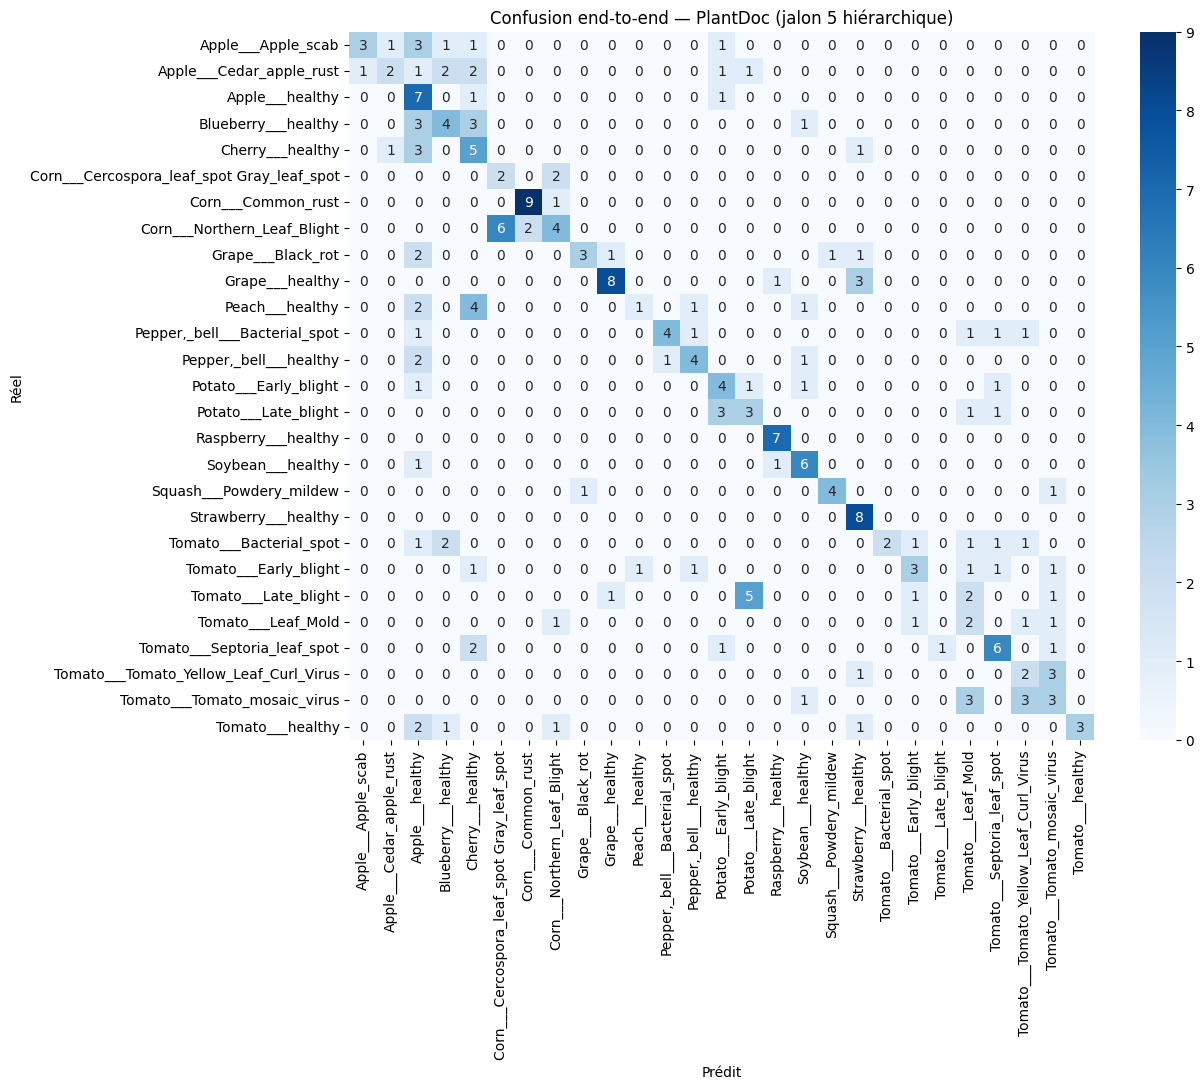

In [24]:
# Matrice de confusion end-to-end (top-1)
labels_present = sorted(set(y_pdtest_pos.tolist()))
cm = confusion_matrix(y_pdtest_pos, pred_pos_pd, labels=labels_present)
fig, ax = plt.subplots(figsize=(13, 11))
ticklabels = [pos_to_name[p] for p in labels_present]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=ticklabels, yticklabels=ticklabels)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('Confusion end-to-end — PlantDoc (jalon 5 hiérarchique)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'jalon5_plantdoc_confusion_matrix.png', dpi=100)
plt.show()

In [ ]:
# Évaluation end-to-end sur PlantVillage test (univers 27)
CHUNK = 512
buf_imgs, buf_true = [], []
ypv_pos, pv_pred_pos = [], []
pv_top3_hits = 0

def _flush_pv(buf_imgs, buf_true):
    global pv_top3_hits
    arr = np.asarray(buf_imgs, dtype=np.float32)
    fp  = predict_joint_distribution(arr)
    pp  = np.argmax(fp, axis=1)
    t3  = np.argsort(-fp, axis=1)[:, :3]
    pv_pred_pos.extend(pp.tolist())
    ypv_pos.extend(buf_true)
    pv_top3_hits += int(sum(t in row for t, row in zip(buf_true, t3)))

for image, label in pv_test_raw:
    g = int(label.numpy())
    if g not in allowed_set:
        continue
    img = tf.image.resize(image, IMG_SIZE)
    buf_imgs.append(tf.cast(img, tf.float32).numpy())
    buf_true.append(global_to_pos[g])
    if len(buf_imgs) >= CHUNK:
        _flush_pv(buf_imgs, buf_true)
        buf_imgs, buf_true = [], []
if buf_imgs:
    _flush_pv(buf_imgs, buf_true)

ypv_pos     = np.array(ypv_pos)
pv_pred_pos = np.array(pv_pred_pos)
pv_top1 = accuracy_score(ypv_pos, pv_pred_pos)
pv_top3 = pv_top3_hits / len(ypv_pos)
pv_f1   = f1_score(ypv_pos, pv_pred_pos, average='macro', zero_division=0)
print(f'PlantVillage test (27 classes) — Top-1 : {pv_top1*100:.2f} % | '
      f'Top-3 : {pv_top3*100:.2f} % | Macro F1 : {pv_f1*100:.2f} %')

PlantVillage test (27 classes) — Top-1 : 80.16 % | Top-3 : 95.30 % | Macro F1 : 75.40 %


## Synthèse

In [ ]:
results = {
    'scope': 'restricted_27_plantdoc_classes',
    'n_species': n_species,
    'n_specialists': len(specialists),
    'species_top1_plantdoc': float(sp_acc),
    'species_macro_f1_plantdoc': float(sp_f1),
    'e2e_plantdoc_top1': float(top1),
    'e2e_plantdoc_top2': float(top2),
    'e2e_plantdoc_top3': float(top3),
    'e2e_plantdoc_macro_f1': float(e2e_f1),
    'e2e_plantdoc_mean_confidence': float(mean_conf),
    'e2e_plantvillage_top1': float(pv_top1),
    'e2e_plantvillage_top3': float(pv_top3),
    'e2e_plantvillage_macro_f1': float(pv_f1),
}
with open(REPORT_DIR / 'jalon4_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('='*70)
print('SYNTHÈSE — Jalon 4 (hiérarchique, univers 27 classes)')
print('='*70)
print(f"Étage 1 espèce  — PlantDoc top-1 : {sp_acc*100:5.2f} %  | macroF1 {sp_f1*100:.2f} %")
print(f"End-to-end      — PlantDoc top-1 : {top1*100:5.2f} %")
print(f"                — PlantDoc top-2 : {top2*100:5.2f} %")
print(f"                — PlantDoc top-3 : {top3*100:5.2f} %")
print(f"                — PlantVillage top-1 : {pv_top1*100:5.2f} %")
print('='*70)
print('Résultats → reports/jalon4_results.json')

SYNTHÈSE — Jalon 5 (hiérarchique, univers 27 classes)
Étage 1 espèce  — PlantDoc top-1 : 69.92 %  | macroF1 63.37 %
End-to-end      — PlantDoc top-1 : 46.19 %
                — PlantDoc top-2 : 62.71 %
                — PlantDoc top-3 : 74.58 %
                — PlantVillage top-1 : 80.16 %
Résultats → reports/jalon5_results.json
